In [13]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import Model
from tensorflow.keras.layers import Conv2D, Dense, MaxPooling2D, Dropout, Flatten,GlobalAveragePooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.applications.inception_v3 import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator,load_img
from tensorflow.keras.models import Sequential
import numpy as np
from glob import glob
import os
import random
from PIL import Image

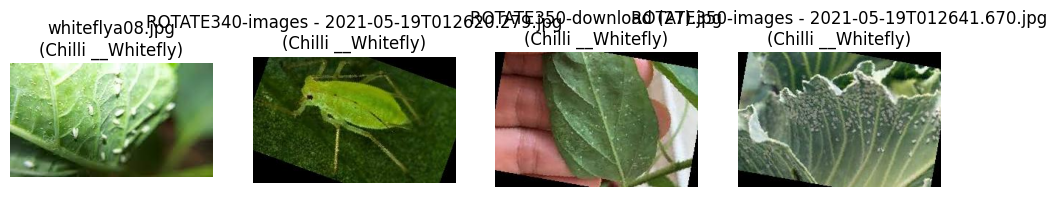

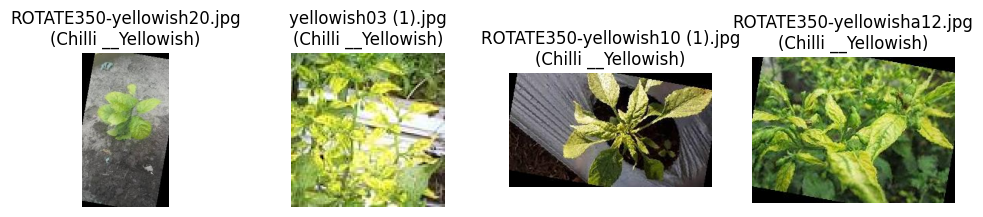

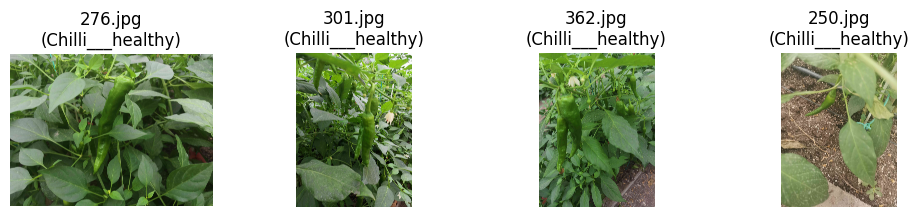

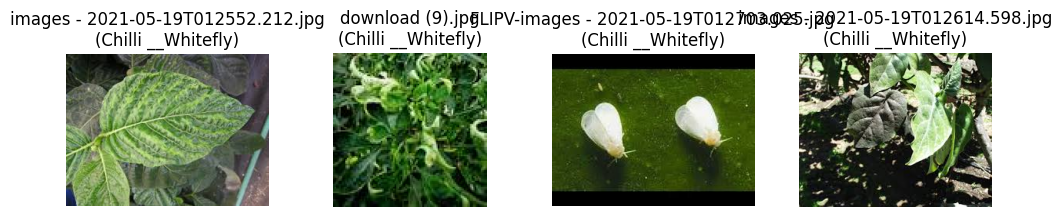

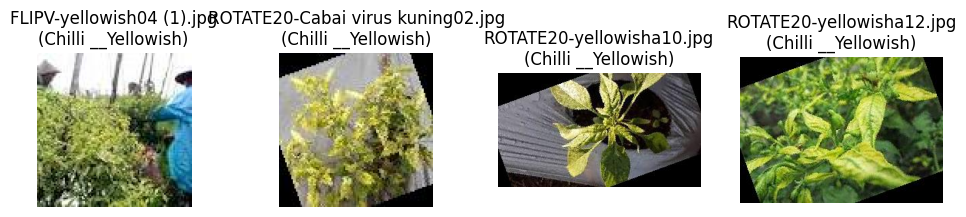

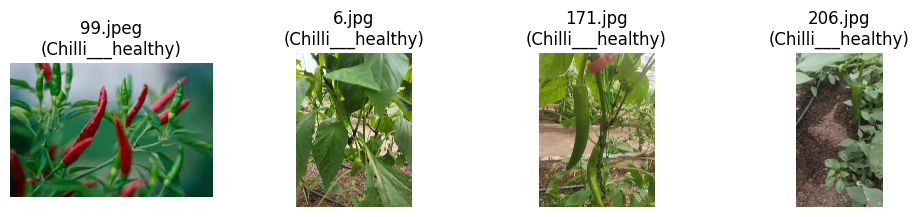

In [14]:
def random_photos_from_folders(base_folder):
    for root, dirs, files in os.walk(base_folder):
        images = [file for file in files if file.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if len(images) >= 4:  
            selected_images = random.sample(images, 4)  
            
            fig, axs = plt.subplots(1, 4, figsize=(12, 2))  
            for idx, img_name in enumerate(selected_images):
                img_path = os.path.join(root, img_name)
                img = Image.open(img_path)
                axs[idx].imshow(img)
                axs[idx].axis('off') 
                
                subfolder_name = os.path.basename(root)
                axs[idx].set_title(f"{img_name}\n({subfolder_name})")
                
            plt.show()

path='dataset'
random_photos_from_folders(path)

In [15]:
train_datagen = ImageDataGenerator(
    rescale=1./255, 
    rotation_range=30, 
    width_shift_range=0.2, 
    height_shift_range=0.2, 
    shear_range=0.2, 
    zoom_range=0.2, 
    horizontal_flip=True, 
    fill_mode='nearest')

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)  


In [17]:
training_set = train_datagen.flow_from_directory(r'dataset/train',
                                                target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='categorical')

Found 1050 images belonging to 3 classes.


In [18]:
test_set = train_datagen.flow_from_directory(r'dataset/test',
                                                target_size=(224, 224),
                                                batch_size=32,
                                                class_mode='categorical',
                                                shuffle=False
                                                )

Found 450 images belonging to 3 classes.


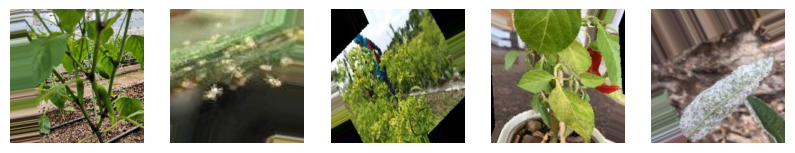

In [19]:
images, labels = next(training_set)  

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])  
    plt.axis("off") 
plt.show()

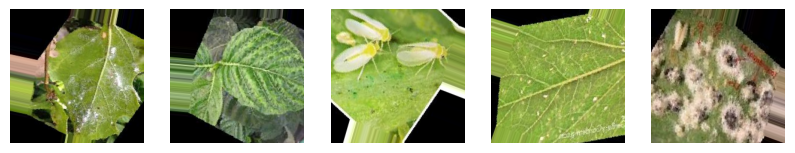

In [20]:
images, labels = next(test_set)  

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])  
    plt.axis("off") 
plt.show()

In [21]:
inception_v3 = tf.keras.applications.InceptionV3(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

In [22]:
for layer in inception_v3.layers[: -15]:
    layer.trainable = False

In [23]:
from tensorflow.keras.regularizers import l2

x = Flatten()(inception_v3.output)
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)  # Increased dropout
x = Dense(512, activation='relu', kernel_regularizer=l2(0.001))(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

model = Model(inputs=inception_v3.input, outputs=output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_188 (Conv2D) │ (None, 111, 111,  │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_188[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_188      │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_189 (Conv2D) │ (None, 109, 109,  │      9,216 │ activation_188[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_189[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_189      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_190 (Conv2D) │ (None, 109, 109,  │     18,432 │ activation_189[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_190[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_190      │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_8     │ (None, 54, 54,    │          0 │ activation_190[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_191 (Conv2D) │ (None, 54, 54,    │      5,120 │ max_pooling2d_8[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_191[0][0]  │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_191      │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_192 (Conv2D) │ (None, 52, 52,    │    138,240 │ activation_191[0… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_192[0][0]  │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_192      │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 48,281,891 (184.18 MB)

 Trainable params: 26,873,987 (102.52 MB)

 Non-trainable params: 21,407,904 (81.66 MB)

In [24]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [25]:
histry = model.fit(training_set,
                            validation_data=test_set,
                            epochs=35,
                            steps_per_epoch=len(training_set),
                            validation_steps=len(test_set),
                            )

c:\Users\Admin\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 160s 5s/step - accuracy: 0.5358 - loss: 11.1434 - val_accuracy: 0.8822 - val_loss: 2.8952
Epoch 2/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 133s 4s/step - accuracy: 0.7982 - loss: 4.0643 - val_accuracy: 0.9089 - val_loss: 2.1502
Epoch 3/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 130s 4s/step - accuracy: 0.8368 - loss: 2.5695 - val_accuracy: 0.9289 - val_loss: 1.8948
Epoch 4/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.8840 - loss: 2.0118 - val_accuracy: 0.9311 - val_loss: 1.7889
Epoch 5/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 126s 4s/step - accuracy: 0.8874 - loss: 1.9222 - val_accuracy: 0.9556 - val_loss: 1.5862
Epoch 6/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.9097 - loss: 1.7298 - val_accuracy: 0.9689 - val_loss: 1.4995
Epoch 7/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9178 - loss: 1.5568 - val_accuracy: 0.9444 - val_loss: 1.4136
Epoch 8/35
33/33 ━━━━━━━━━━━━━━━━━━━━ 125s 4s/step - accuracy: 0.9263 - loss: 1.5176 - val_accuracy: 0.9400 - 

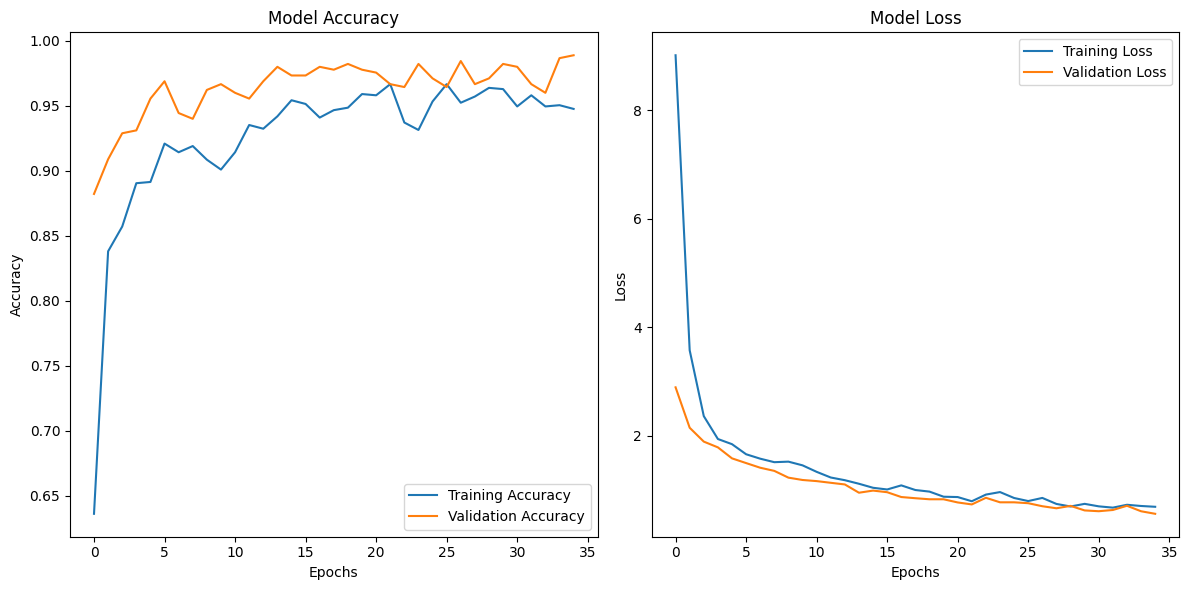

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(histry.history['accuracy'], label='Training Accuracy')
plt.plot(histry.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(histry.history['loss'], label='Training Loss')
plt.plot(histry.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [27]:
model.save("chilli_model.h5")